# Perceptron — Attrition Prediction

## Perceptron Implementation (From Scratch)

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import Perceptron as SklearnPerceptron

In [ ]:
class Perceptron:

    def __init__(self, input_dim):
        self.W = np.zeros((input_dim, 1))  
        self.b = 0.0                        
        self.errors_per_epoch = []         

    @staticmethod
    def step(Z):
        #Step activation: returns 1 if Z >= 0, else 0.
        return (Z >= 0).astype(int)

    def predict(self, X):
        Z = np.dot(X, self.W) + self.b
        return self.step(Z)

    def train(self, X, y, epochs=50000, learning_rate=0.05, print_every=1000):
        m = X.shape[0]
        for epoch in range(epochs):
            predictions = self.predict(X)
            errors = y - predictions  # +1 if missed positive, -1 if missed negative, 0 if correct
            n_errors = np.sum(errors != 0)
            self.errors_per_epoch.append(n_errors)

            # W += lr * X^T · (y - pred) / m
            self.W += learning_rate * np.dot(X.T, errors) / m
            self.b += learning_rate * np.sum(errors) / m

            if print_every and epoch % print_every == 0:
                acc = np.mean(predictions == y)
                print(f"Epoch {epoch:>4d} | Errors: {n_errors:>4d}/{m} | Train Acc: {acc:.4f}")

## Load & Prepare Data

In [ ]:
df = pd.read_csv("../data/processed_data_attrition.csv")

# Convert standardized Attrition values back to binary
attrition_vals = sorted(df["Attrition"].unique())
df["Attrition"] = df["Attrition"].map({attrition_vals[0]: 0, attrition_vals[1]: 1})

# Separate features and target
X = df.drop("Attrition", axis=1).values
y = df["Attrition"].values.reshape(-1, 1)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Attrition rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Features: 36
Train: 1971 samples | Test: 493 samples
Attrition rate — Train: 50.03% | Test: 49.90%


## Train the Model

In [ ]:
np.random.seed(42)

# Perceptron: 36 features -> 1 output
perceptron = Perceptron(input_dim=X_train.shape[1])

perceptron.train(X_train, y_train, epochs=500, learning_rate=0.05, print_every=1000)

Epoch    0 | Errors:  985/1971 | Train Acc: 0.5003


## Performance Curve

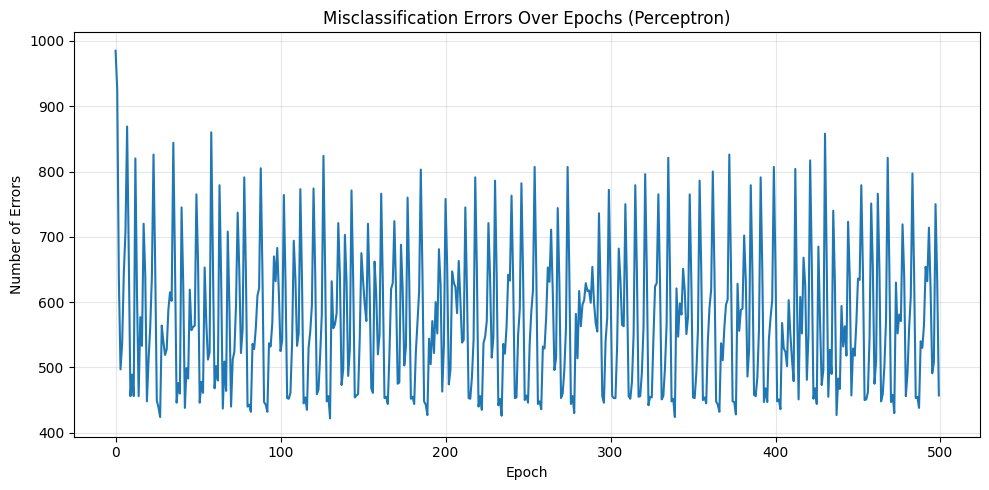

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(perceptron.errors_per_epoch)
plt.title("Misclassification Errors Over Epochs (Perceptron)")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [ ]:
y_pred_perceptron = perceptron.predict(X_test)

# Accuracy, Precision, Recall, F1 score
accuracy = accuracy_score(y_test, y_pred_perceptron)
precision = precision_score(y_test, y_pred_perceptron)
recall = recall_score(y_test, y_pred_perceptron)
f1 = f1_score(y_test, y_pred_perceptron)

# Specificity (True Negative Rate)
cm = confusion_matrix(y_test, y_pred_perceptron)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("=" * 45)
print("    Perceptron — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_perceptron, target_names=["No Attrition", "Attrition"]))

    Perceptron — Evaluation Results
  Accuracy:    0.7343
  Precision:   0.7328
  Recall:      0.7358
  Specificity: 0.7328
  F1 Score:    0.7343

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.74      0.73      0.73       247
   Attrition       0.73      0.74      0.73       246

    accuracy                           0.73       493
   macro avg       0.73      0.73      0.73       493
weighted avg       0.73      0.73      0.73       493



## Confusion Matrix

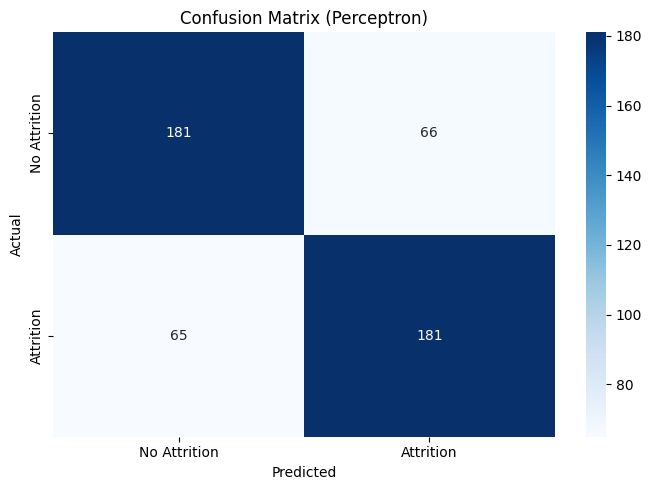

In [ ]:
cm_p = confusion_matrix(y_test, y_pred_perceptron)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (Perceptron)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve & AUC

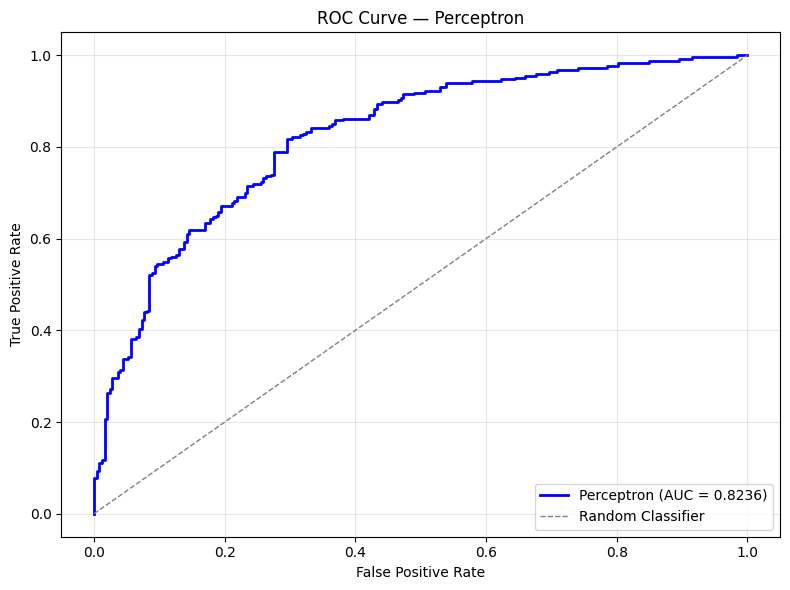

AUC Score: 0.8236


In [ ]:
Z_scores = np.dot(X_test, perceptron.W) + perceptron.b

fpr, tpr, thresholds = roc_curve(y_test, Z_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Perceptron (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perceptron')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

---
# Sklearn Perceptron — Comparison

In [ ]:
sklearn_perceptron = SklearnPerceptron(max_iter=1000, eta0=0.05, random_state=42, tol=None)
sklearn_perceptron.fit(X_train, y_train.ravel())

y_pred_sklearn = sklearn_perceptron.predict(X_test).reshape(-1, 1)

# Accuracy, Precision, Recall, F1 score
accuracy_sk = accuracy_score(y_test, y_pred_sklearn)
precision_sk = precision_score(y_test, y_pred_sklearn)
recall_sk = recall_score(y_test, y_pred_sklearn)
f1_sk = f1_score(y_test, y_pred_sklearn)

cm_sk = confusion_matrix(y_test, y_pred_sklearn)
tn_sk, fp_sk, fn_sk, tp_sk = cm_sk.ravel()
specificity_sk = tn_sk / (tn_sk + fp_sk) if (tn_sk + fp_sk) > 0 else 0

# ROC/AUC for sklearn
Z_scores_sk = sklearn_perceptron.decision_function(X_test)
fpr_sk, tpr_sk, _ = roc_curve(y_test, Z_scores_sk)
auc_sk = auc(fpr_sk, tpr_sk)

print("=" * 45)
print("    Sklearn Perceptron — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {accuracy_sk:.4f}")
print(f"  Precision:   {precision_sk:.4f}")
print(f"  Recall:      {recall_sk:.4f}")
print(f"  Specificity: {specificity_sk:.4f}")
print(f"  F1 Score:    {f1_sk:.4f}")
print(f"  AUC:         {auc_sk:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sklearn, target_names=["No Attrition", "Attrition"]))

    Sklearn Perceptron — Evaluation Results
  Accuracy:    0.7079
  Precision:   0.7040
  Recall:      0.7154
  Specificity: 0.7004
  F1 Score:    0.7097
  AUC:         0.7673

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.71      0.70      0.71       247
   Attrition       0.70      0.72      0.71       246

    accuracy                           0.71       493
   macro avg       0.71      0.71      0.71       493
weighted avg       0.71      0.71      0.71       493



## Confusion Matrix (Sklearn Perceptron)

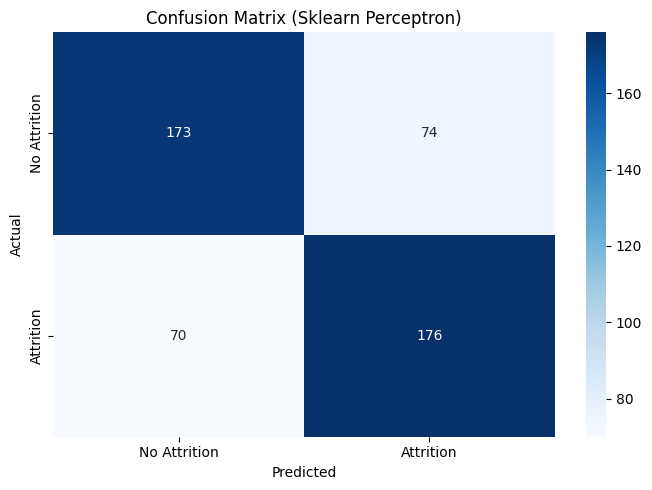

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_sk, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (Sklearn Perceptron)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve & AUC (Sklearn Perceptron)

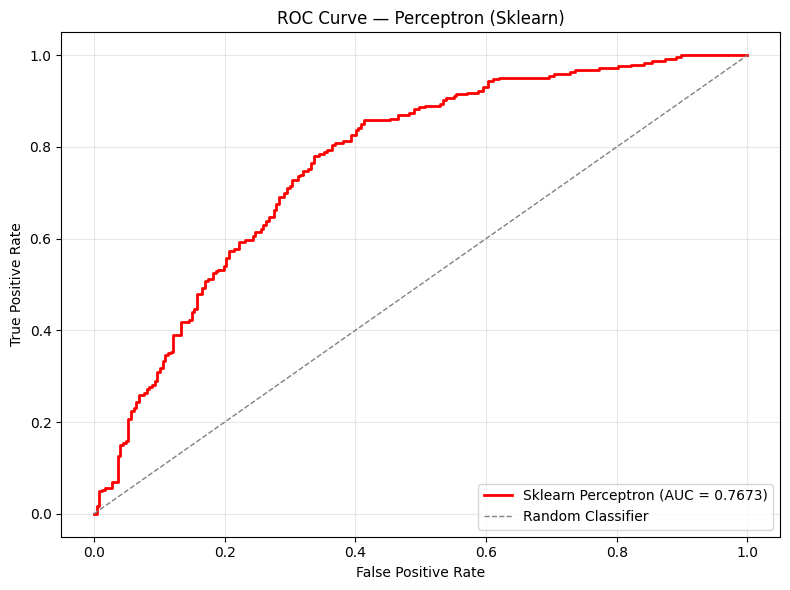

AUC Score (Sklearn): 0.7673


In [56]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_sk, tpr_sk, color='red', lw=2, label=f'Sklearn Perceptron (AUC = {auc_sk:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perceptron (Sklearn)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score (Sklearn): {auc_sk:.4f}")

## Performance Curve (Sklearn Perceptron)

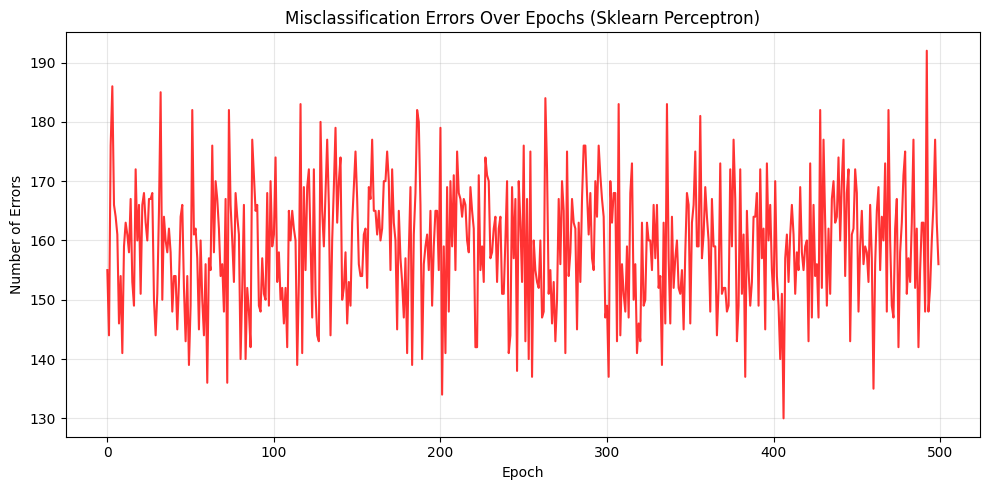

In [60]:
# Track misclassification errors over epochs using partial_fit
sklearn_perc_curve = SklearnPerceptron(eta0=0.05, random_state=42, tol=None, max_iter=1, warm_start=True)
sklearn_errors = []

for epoch in range(500):
    sklearn_perc_curve.fit(X_train, y_train.ravel())
    y_pred_epoch = sklearn_perc_curve.predict(X_test).reshape(-1, 1)
    n_errors = np.sum(y_pred_epoch != y_test)
    sklearn_errors.append(n_errors)

plt.figure(figsize=(10, 5))
plt.plot(sklearn_errors, color='red', alpha=0.8)
plt.title("Misclassification Errors Over Epochs (Sklearn Perceptron)")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison: From Scratch vs Sklearn

  Perceptron Comparison: From Scratch vs Sklearn
             Perceptron (Scratch)  Perceptron (Sklearn)
Metric                                                 
Accuracy                 0.734280              0.707911
Precision                0.732794              0.704000
Recall                   0.735772              0.715447
Specificity              0.732794              0.700405
F1 Score                 0.734280              0.709677
AUC                      0.823623              0.767305


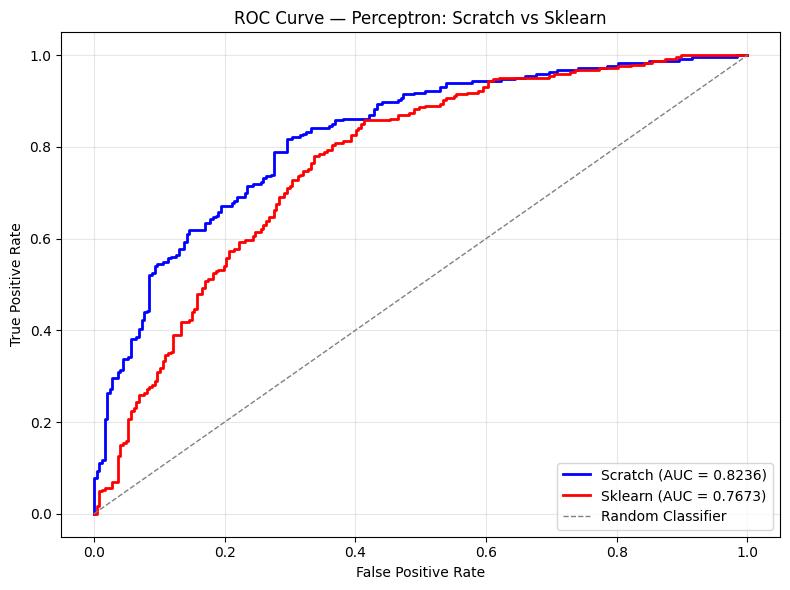

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "AUC"],
    "Perceptron (Scratch)": [accuracy, precision, recall, specificity, f1, roc_auc],
    "Perceptron (Sklearn)": [accuracy_sk, precision_sk, recall_sk, specificity_sk, f1_sk, auc_sk]
})
comparison = comparison.set_index("Metric")
print("=" * 55)
print("  Perceptron Comparison: From Scratch vs Sklearn")
print("=" * 55)
print(comparison.to_string())
print("=" * 55)

# ROC Curve comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Scratch (AUC = {roc_auc:.4f})')
plt.plot(fpr_sk, tpr_sk, color='red', lw=2, label=f'Sklearn (AUC = {auc_sk:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perceptron: Scratch vs Sklearn')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()